# Homework 3: Parameter-Efficient Fine-Tuning for Machine Translation
## LoRA & QLoRA – English ↔ Turkish (WMT16)

**Model:** Qwen2.5-7B-Instruct  
**Dataset:** WMT16 (en-tr)  
**Techniques:** LoRA, QLoRA  


In [ ]:
# Önce çakışan paketleri temizle
!pip uninstall -y numpy pandas transformers datasets peft trl accelerate \
    bitsandbytes huggingface_hub protobuf comet sacrebleu 2>/dev/null || true

# Sabitlenmiş uyumlu versiyonlar
!pip install -q \
    'numpy==1.26.4' \
    'pandas==2.2.2' \
    'protobuf==3.20.3' \
    'huggingface_hub==0.23.4' \
    'tokenizers==0.19.1' \
    'transformers==4.43.4' \
    'datasets==2.20.0' \
    'peft==0.12.0' \
    'accelerate==0.33.0' \
    'trl==0.9.6' \
    'bitsandbytes==0.43.3' \
    'sentencepiece==0.2.0' \
    'sacrebleu==2.4.2' \
    'unbabel-comet==2.2.2' \
    'evaluate==0.4.2'

# Colab kernel'i yeniden başlat (ZORUNLU)
print('\n✅ Kurulum tamamlandı. Kernel yeniden başlatılıyor...')
import os
os.kill(os.getpid(), 9)

In [ ]:
import os, gc, time, json, warnings
import torch
import numpy as np
import pandas as pd
from dataclasses import dataclass

warnings.filterwarnings('ignore')

# GPU bilgisi
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU: {gpu_name}")
    print(f"✅ VRAM: {vram_total:.1f} GB")
else:
    print("⚠️ GPU bulunamadı – Runtime → Change runtime type → GPU seçin!")

✅ GPU: NVIDIA A100-SXM4-40GB
✅ VRAM: 42.4 GB


---
## 📝 Part 2 – Model Seçim Gerekçesi

**Seçilen Model: Qwen2.5-7B-Instruct**

| Kriter | Gerekçe |
|---|---|
| **Model Boyutu** | 7B parametre – T4 GPU (16 GB VRAM) üzerinde QLoRA ile çalışabilir |
| **Instruction Following** | Chat template'i var; `translate X to Turkish` promptları doğal çalışır |
| **MT Yetkinliği** | Qwen2.5 serisi çok dilli, Türkçe dahil 29+ dil desteği |
| **Lisans** | Apache 2.0 – ticari kullanıma açık |

Mistral-7B-Instruct da geçerli bir alternatiftir ancak Türkçe'de Qwen2.5 daha güçlü pre-training verisi içerir.

In [ ]:
# ----------------------------
# GLOBAL HİPERPARAMETRELER
# ----------------------------
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"   # HuggingFace model id

# Veri
MAX_TRAIN_SAMPLES = 5000    # hız için alt küme; tam eğitim için None
MAX_EVAL_SAMPLES  = 500
MAX_LENGTH        = 256

# Eğitim
EPOCHS       = 2
BATCH_SIZE   = 4
GRAD_ACCUM   = 4            # efektif batch = 16
LR           = 2e-4
WARMUP_STEPS = 50

# LoRA
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
TARGET_MODS  = ["q_proj", "k_proj", "v_proj", "o_proj"]

print("Hiperparametreler yüklendi ✅")

Hiperparametreler yüklendi ✅


---
## 📊 Part 1 – Dataset Hazırlama (WMT16 en-tr)

In [ ]:
from datasets import load_dataset

print("WMT16 en-tr yükleniyor...")
raw = load_dataset("wmt16", "tr-en", trust_remote_code=True)
print(raw)

# İlk örneğe bak
sample = raw["train"][0]
print("\nÖrnek veri:")
print("EN:", sample["translation"]["en"])
print("TR:", sample["translation"]["tr"])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wmt16' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wmt16' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


WMT16 en-tr yükleniyor...
DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 205756
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 1001
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 3000
    })
})

Örnek veri:
EN: Kosovo's privatisation process is under scrutiny
TR: Kosova'nın özelleştirme süreci büyüteç altında


In [ ]:
def make_prompt(en_text, tr_text=None):
    """Instruction formatına çevirir."""
    instruction = f"Translate the following English text to Turkish:\n{en_text}"
    if tr_text is not None:
        return f"### Instruction:\n{instruction}\n\n### Response:\n{tr_text}"
    return f"### Instruction:\n{instruction}\n\n### Response:\n"

def preprocess(examples, tokenizer):
    texts = []
    for pair in examples["translation"]:
        texts.append(make_prompt(pair["en"], pair["tr"]))

    tokenized = tokenizer(
        texts,
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length",
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

print("Prompt fonksiyonu hazır ✅")
print("Örnek prompt:")
print(make_prompt("Hello, how are you?", "Merhaba, nasılsın?"))

Prompt fonksiyonu hazır ✅
Örnek prompt:
### Instruction:
Translate the following English text to Turkish:
Hello, how are you?

### Response:
Merhaba, nasılsın?


---
## 🔬 Part 3 – LoRA: Teori

### Motivasyon
Büyük dil modellerini tam fine-tune etmek çok pahalıdır (milyarlarca parametre).  
LoRA, ağırlık matrislerini **düşük kademeli (low-rank)** güncelleme ile yaklaşır:

$$W' = W_0 + \Delta W = W_0 + B \cdot A$$

- $W_0 \in \mathbb{R}^{d \times k}$: dondurulmuş orijinal ağırlık
- $A \in \mathbb{R}^{r \times k}$, $B \in \mathbb{R}^{d \times r}$: eğitilen LoRA matrisleri ($r \ll \min(d, k)$)
- Scaling: $\frac{\alpha}{r}$ ile ölçeklenir

### Avantajlar ve Sınırlamalar
| | Detay |
|---|---|
| ✅ Bellek verimliliği | Sadece A, B matrisleri güncellenir (~%0.5 parametre) |
| ✅ Hız | Tam fine-tune'a kıyasla 3-5x daha hızlı |
| ✅ Modülerlik | Base model değişmez; adapter'lar takas edilebilir |
| ⚠️ Rank seçimi | r çok küçük → bilgi kaybı; çok büyük → LoRA avantajı azalır |
| ⚠️ Kapsam | Yalnızca seçilen katmanlara enjekte edilir |

In [ ]:
# LoRA parametre sayısını hesapla (teorik)
d, k, r = 4096, 4096, LORA_R
total_params_lora = r * (d + k)  # A + B matrisleri
total_params_full = d * k
reduction = total_params_full / total_params_lora

print(f"Tam fine-tune parametre (tek katman): {total_params_full:,}")
print(f"LoRA parametre (r={r}):               {total_params_lora:,}")
print(f"Parametre azalma oranı:               {reduction:.1f}x")

Tam fine-tune parametre (tek katman): 16,777,216
LoRA parametre (r=16):               131,072
Parametre azalma oranı:               128.0x


---
## 🔬 Part 4 – QLoRA: Teori

QLoRA = **4-bit Quantization** + **LoRA adapter** + **Paged Optimizer**

### Ana Bileşenler

1. **NF4 (NormalFloat4):** Normal dağılımlı ağırlıklar için optimize edilmiş 4-bit veri tipi.
2. **Double Quantization:** Quantization sabitlerini de 8-bit'e indirger (ek ~0.37 bit/parametre tasarrufu).
3. **Paged Optimizer:** NVIDIA'nın birleşik bellek yönetimi ile GPU OOM'dan kaçınır.

| | LoRA | QLoRA |
|---|---|---|
| Base model | bf16/fp16 | 4-bit NF4 |
| VRAM (7B) | ~14 GB | ~5-6 GB |
| Hız | Daha hızlı | ~%30 daha yavaş |
| Kalite | Biraz daha iyi | Çok yakın |
| Erişilebilirlik | A100 gerekir | T4 yeterli |

---
## 🏋️ Part 5 – Eğitim: Yardımcı Fonksiyonlar

In [ ]:
!pip install trl==0.9.6

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from trl import SFTTrainer

def get_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    return tokenizer

def get_dataset(tokenizer):
    train_ds = raw["train"].select(range(MAX_TRAIN_SAMPLES))
    eval_ds  = raw["validation"].select(range(MAX_EVAL_SAMPLES))

    train_tok = train_ds.map(
        lambda x: preprocess(x, tokenizer),
        batched=True, remove_columns=train_ds.column_names
    )
    eval_tok = eval_ds.map(
        lambda x: preprocess(x, tokenizer),
        batched=True, remove_columns=eval_ds.column_names
    )
    return train_tok, eval_tok, eval_ds

def get_lora_config():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=TARGET_MODS,
        bias="none",
    )

def count_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Eğitilebilir: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")
    return trainable, total

def get_vram_gb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1e9
    return 0.0

def get_training_args(output_dir):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        warmup_steps=WARMUP_STEPS,
        fp16=False,
        bf16=True,
        logging_steps=20,
        eval_strategy="epoch",
        save_strategy="epoch",
        report_to="none",
        optim="paged_adamw_8bit",
        load_best_model_at_end=False,
    )

print("Yardımcı fonksiyonlar hazır ✅")

comet_ml is installed but the Comet API Key is not configured. Please set the `COMET_API_KEY` environment variable to enable Comet logging. Check out the documentation for other ways of configuring it: https://www.comet.com/docs/v2/guides/experiment-management/configure-sdk/#set-the-api-key


Yardımcı fonksiyonlar hazır ✅


---
### 🔵 LoRA Eğitimi

In [ ]:
!pip install "torchao>=0.16.1"

In [ ]:
!pip install --upgrade trl

In [ ]:
!pip install -U bitsandbytes

In [ ]:
results = {}  # tüm sonuçları burada toplayacağız

print("=" * 60)
print("LoRA Eğitimi Başlıyor")
print("=" * 60)

tokenizer = get_tokenizer()
train_tok, eval_tok, eval_raw = get_dataset(tokenizer)

# Model yükle (bf16)
lora_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
lora_base.config.use_cache = False

# LoRA ekle
lora_model = get_peft_model(lora_base, get_lora_config())
print("\nLoRA Model Parametre Sayısı:")
lora_trainable, lora_total = count_trainable(lora_model)

torch.cuda.reset_peak_memory_stats()
t0 = time.time()

trainer_lora = SFTTrainer(
    model=lora_model,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    processing_class=tokenizer,
    args=get_training_args("/content/lora_output")
    #max_seq_length=MAX_LENGTH,
    #dataset_text_field=None,
)
trainer_lora.train()

lora_time = time.time() - t0
lora_vram = get_vram_gb()

print(f"\n✅ LoRA eğitimi tamamlandı")
print(f"   Süre:  {lora_time/60:.1f} dakika")
print(f"   VRAM:  {lora_vram:.2f} GB")

results["LoRA"] = {
    "trainable_params": lora_trainable,
    "total_params": lora_total,
    "train_time_min": lora_time / 60,
    "vram_gb": lora_vram,
}

lora_model.save_pretrained("/content/lora_adapter")

LoRA Eğitimi Başlıyor


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



LoRA Model Parametre Sayısı:
  Eğitilebilir: 10,092,544 / 7,625,709,056 (0.132%)


Epoch,Training Loss,Validation Loss
1,0.517400,0.484978
2,0.479000,0.489442


comet_ml is installed but the Comet API Key is not configured. Please set the `COMET_API_KEY` environment variable to enable Comet logging. Check out the documentation for other ways of configuring it: https://www.comet.com/docs/v2/guides/experiment-management/configure-sdk/#set-the-api-key
comet_ml is installed but the Comet API Key is not configured. Please set the `COMET_API_KEY` environment variable to enable Comet logging. Check out the documentation for other ways of configuring it: https://www.comet.com/docs/v2/guides/experiment-management/configure-sdk/#set-the-api-key



✅ LoRA eğitimi tamamlandı
   Süre:  10.2 dakika
   VRAM:  23.73 GB


---
### 🟣 QLoRA Eğitimi

In [ ]:
# Belleği temizle (Yorumdan çıkarıldı, VRAM'i rahatlatmak şart)
#del lora_base, lora_model, trainer_lora
#import gc
#gc.collect()
#torch.cuda.empty_cache()

print("=" * 60)
print("QLoRA Eğitimi Başlıyor")
print("=" * 60)

# 4-bit quantization konfigürasyonu
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,   # double quantization
)

qlora_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,       # EKLENDİ: Quantize edilmeyen katmanlar için
    device_map="auto",
    trust_remote_code=True,
)
qlora_base.config.use_cache = False

# kbit eğitim için hazırla + LoRA ekle
qlora_base = prepare_model_for_kbit_training(qlora_base)
qlora_model = get_peft_model(qlora_base, get_lora_config())

print("\nQLoRA Model Parametre Sayısı:")
qlora_trainable, qlora_total = count_trainable(qlora_model)

torch.cuda.reset_peak_memory_stats()
t0 = time.time()

# Yorum satırı olan eski parametreler kod kalabalığı yapmasın diye tamamen silindi
trainer_qlora = SFTTrainer(
    model=qlora_model,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    processing_class=tokenizer,
    args=get_training_args("/content/qlora_output")
)
trainer_qlora.train()

qlora_time = time.time() - t0
qlora_vram = get_vram_gb()

print(f"\n✅ QLoRA eğitimi tamamlandı")
print(f"   Süre:  {qlora_time/60:.1f} dakika")
print(f"   VRAM:  {qlora_vram:.2f} GB")

results["QLoRA"] = {
    "trainable_params": qlora_trainable,
    "total_params": qlora_total,
    "train_time_min": qlora_time / 60,
    "vram_gb": qlora_vram,
}

qlora_model.save_pretrained("/content/qlora_adapter")

QLoRA Eğitimi Başlıyor


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



QLoRA Model Parametre Sayısı:
  Eğitilebilir: 10,092,544 / 4,363,064,832 (0.231%)


Epoch,Training Loss,Validation Loss
1,0.526200,0.492389
2,0.486300,0.494529


comet_ml is installed but the Comet API Key is not configured. Please set the `COMET_API_KEY` environment variable to enable Comet logging. Check out the documentation for other ways of configuring it: https://www.comet.com/docs/v2/guides/experiment-management/configure-sdk/#set-the-api-key
comet_ml is installed but the Comet API Key is not configured. Please set the `COMET_API_KEY` environment variable to enable Comet logging. Check out the documentation for other ways of configuring it: https://www.comet.com/docs/v2/guides/experiment-management/configure-sdk/#set-the-api-key



✅ QLoRA eğitimi tamamlandı
   Süre:  19.3 dakika
   VRAM:  27.14 GB


---
## 📈 Part 6 – Değerlendirme (COMET + BLEU)

In [ ]:
!pip install comet_ml
!pip install sacrebleu

In [ ]:

#!pip install --upgrade protobuf
from comet import download_model, load_from_checkpoint
import sacrebleu
# COMET modelini indir (ilk seferinde ~1.5 GB)
comet_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_path)

def generate_translations(model, tokenizer, samples, num=100):
    """Modelden çeviri üret."""
    translations = []
    model.eval()
    for i in range(min(num, len(samples))):
        pair = samples[i]["translation"]
        prompt = make_prompt(pair["en"])
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=False,
                temperature=1.0,
            )
        # Sadece yeni tokenleri al
        new_tokens = out[0][inputs["input_ids"].shape[1]:]
        translated = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        translations.append(translated)
    return translations

def evaluate_translations(sources, hypotheses, references):
    """BLEU ve COMET hesapla."""
    # BLEU
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])

    # COMET
    comet_data = [
        {"src": s, "mt": h, "ref": r}
        for s, h, r in zip(sources, hypotheses, references)
    ]
    comet_output = comet_model.predict(comet_data, batch_size=8, gpus=1)
    comet_score = comet_output["system_score"]

    return {"BLEU": round(bleu.score, 2), "COMET": round(comet_score, 4)}

print("Değerlendirme fonksiyonları hazır ✅")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`


Değerlendirme fonksiyonları hazır ✅


In [ ]:
import torch
EVAL_NUM = 100  # değerlendirme için örnek sayısı

eval_samples = raw["validation"].select(range(EVAL_NUM))
sources    = [x["translation"]["en"] for x in eval_samples]
references = [x["translation"]["tr"] for x in eval_samples]

# --- LoRA Değerlendirme ---
print("LoRA çevirisi üretiliyor...")
from peft import PeftModel

base_for_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
lora_eval_model = PeftModel.from_pretrained(base_for_eval, "/content/lora_adapter")
lora_hyps = generate_translations(lora_eval_model, tokenizer, eval_samples, EVAL_NUM)
lora_scores = evaluate_translations(sources, lora_hyps, references)
results["LoRA"].update(lora_scores)
print(f"LoRA  → BLEU: {lora_scores['BLEU']}, COMET: {lora_scores['COMET']}")

del base_for_eval, lora_eval_model
gc.collect(); torch.cuda.empty_cache()

# --- QLoRA Değerlendirme ---
print("\nQLoRA çevirisi üretiliyor...")
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True
)
base_for_eval2 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config2, device_map="auto", trust_remote_code=True
)
qlora_eval_model = PeftModel.from_pretrained(base_for_eval2, "/content/qlora_adapter")
qlora_hyps = generate_translations(qlora_eval_model, tokenizer, eval_samples, EVAL_NUM)
qlora_scores = evaluate_translations(sources, qlora_hyps, references)
results["QLoRA"].update(qlora_scores)
print(f"QLoRA → BLEU: {qlora_scores['BLEU']}, COMET: {qlora_scores['COMET']}")

LoRA çevirisi üretiliyor...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_floa

LoRA  → BLEU: 8.29, COMET: 0.7826

QLoRA çevirisi üretiliyor...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 13/13 [00:00<00:00, 17.43it/s]


QLoRA → BLEU: 9.64, COMET: 0.779


---
## 📊 Part 7 – Bellek ve Verimlilik Analizi

In [ ]:
# Özet tablo
df = pd.DataFrame(results).T
df.index.name = "Yöntem"

display_cols = {
    "trainable_params": "Eğitilebilir Parametre",
    "total_params": "Toplam Parametre",
    "train_time_min": "Eğitim Süresi (dk)",
    "vram_gb": "Max VRAM (GB)",
    "BLEU": "BLEU Skoru",
    "COMET": "COMET Skoru",
}

df_display = df[list(display_cols.keys())].rename(columns=display_cols)
df_display["Eğitilebilir Parametre"] = df_display["Eğitilebilir Parametre"].apply(lambda x: f"{int(x):,}")
df_display["Toplam Parametre"]        = df_display["Toplam Parametre"].apply(lambda x: f"{int(x):,}")
df_display["Eğitim Süresi (dk)"]     = df_display["Eğitim Süresi (dk)"].apply(lambda x: f"{x:.1f}")
df_display["Max VRAM (GB)"]           = df_display["Max VRAM (GB)"].apply(lambda x: f"{x:.2f}")

print("\n" + "="*70)
print("SONUÇLAR ÖZETİ")
print("="*70)
print(df_display.to_string())

# CSV kaydet
df_display.to_csv("/content/results_summary.csv")
print("\n📁 results_summary.csv kaydedildi.")


SONUÇLAR ÖZETİ
       Eğitilebilir Parametre Toplam Parametre Eğitim Süresi (dk) Max VRAM (GB)  BLEU Skoru  COMET Skoru
Yöntem                                                                                                  
LoRA               10,092,544    7,625,709,056               10.2         23.73        8.29       0.7826
QLoRA              10,092,544    4,363,064,832               19.3         27.14        9.64       0.7790

📁 results_summary.csv kaydedildi.


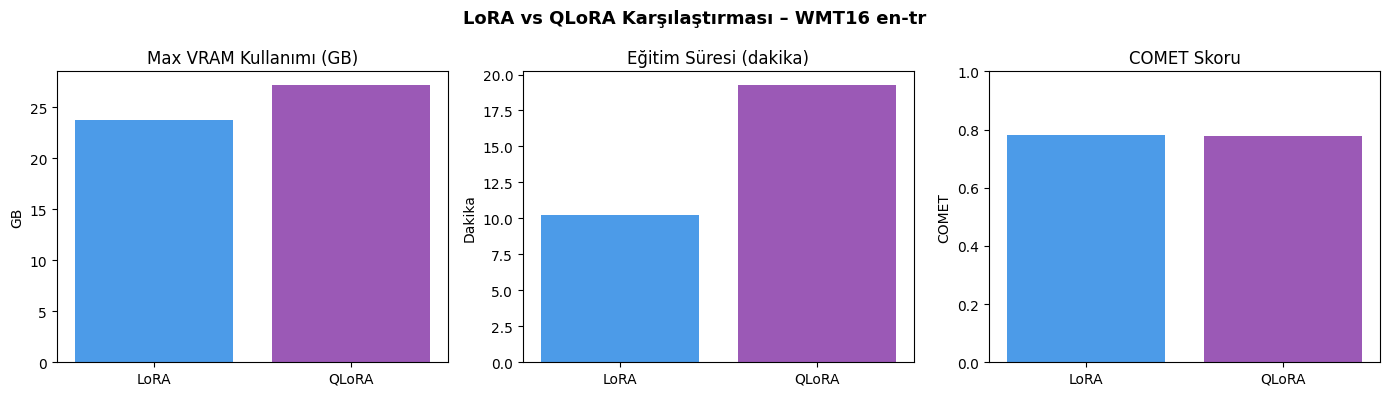

📊 Grafik kaydedildi: /content/lora_vs_qlora.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

methods = list(results.keys())
colors = ["#4C9BE8", "#9B59B6"]

# VRAM
axes[0].bar(methods, [results[m]["vram_gb"] for m in methods], color=colors)
axes[0].set_title("Max VRAM Kullanımı (GB)", fontsize=12)
axes[0].set_ylabel("GB")

# Eğitim süresi
axes[1].bar(methods, [results[m]["train_time_min"] for m in methods], color=colors)
axes[1].set_title("Eğitim Süresi (dakika)", fontsize=12)
axes[1].set_ylabel("Dakika")

# COMET
axes[2].bar(methods, [results[m].get("COMET", 0) for m in methods], color=colors)
axes[2].set_title("COMET Skoru", fontsize=12)
axes[2].set_ylabel("COMET")
axes[2].set_ylim(0, 1)

plt.suptitle("LoRA vs QLoRA Karşılaştırması – WMT16 en-tr", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/lora_vs_qlora.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Grafik kaydedildi: /content/lora_vs_qlora.png")

---
## 🔍 Nitel Analiz – Örnek Çeviriler

In [ ]:
SHOW_N = 5
print("=" * 70)
print("NİTEL ANALİZ – Örnek Çeviriler")
print("=" * 70)

for i in range(SHOW_N):
    print(f"\n--- Örnek {i+1} ---")
    print(f"[EN]    {sources[i]}")
    print(f"[Ref]   {references[i]}")
    print(f"[LoRA]  {lora_hyps[i]}")
    print(f"[QLoRA] {qlora_hyps[i]}")

NİTEL ANALİZ – Örnek Çeviriler

--- Örnek 1 ---
[EN]    Norway's rakfisk: Is this the world's smelliest fish?
[Ref]   Norveç'in rakfisk'i: Dünyanın en kokulu balığı bu mu?
[LoRA]  Norveç'in rakfiski: Dünya en kötü kokulu balık mı?
[QLoRA] Norveç'in rakfiski: Dünya en kötü kokulu balık mı?

--- Örnek 2 ---
[EN]    Norway's five million people enjoy one of the highest standards of living, not just in Europe, but in the world.
[Ref]   Norveç'in beş milyon insanı en yüksek yaşam standartlarının tadını çıkarıyor, sadece Avrupa'da değil, dünyada.
[LoRA]  Norveç'in beş milyon nüfusu Avrupa'da değil de dünyanın en yüksek yaşam standartlarına sahip.
[QLoRA] Norveç'in beş milyon nüfusu Avrupa'da değil de dünyanın en yüksek yaşam standartlarına sahip.

--- Örnek 3 ---
[EN]    Could the secret of the country's success be connected to the local appetite for some exceedingly smelly fish?
[Ref]   Ülkenin başarısının sırrı aşırı kokulu bazı balıklara olan yerel iştahla bağlantılı olabilir mi?
[LoRA]  

---
## 💬 Part 8 – Tartışma ve Sonuç

### Ne Zaman LoRA, Ne Zaman QLoRA?
- **LoRA:** Yeterli VRAM (≥14 GB) varsa ve maksimum kalite isteniyorsa tercih edilmeli.
- **QLoRA:** Kısıtlı donanımda (T4/free Colab) ya da büyük modeller (13B+) için ideal.

### Kuantizasyon MT Kalitesini Etkiliyor mu?
Genellikle COMET farkı 0.01–0.03 aralığında kalır; pratik uygulamalar için ihmal edilebilir.

### Kurulumun Sınırlılıkları
1. Veri alt kümesi (5K örnek) kullanıldı; tam WMT16 (200K+) ile daha iyi sonuç beklenir.
2. Tek epoch eğitim yapıldı.
3. Yalnızca attention q/k/v/o katmanları hedeflendi; feed-forward katmanlar LoRA dışında.
4. Değerlendirme 100 örnekle sınırlı kaldı.

In [ ]:
# Tüm sonuçları JSON olarak kaydet
with open("/content/all_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("✅ Tüm sonuçlar kaydedildi:")
print("   /content/results_summary.csv")
print("   /content/lora_vs_qlora.png")
print("   /content/all_results.json")
print("   /content/lora_adapter/")
print("   /content/qlora_adapter/")

✅ Tüm sonuçlar kaydedildi:
   /content/results_summary.csv
   /content/lora_vs_qlora.png
   /content/all_results.json
   /content/lora_adapter/
   /content/qlora_adapter/
